In [1]:
# Load in our libraries
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold


%matplotlib inline
import torch
import torchvision
from PIL import Image


In [2]:
df = pd.read_pickle("/content/drive/MyDrive/LSWMD.pkl")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [4]:
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [5]:
df.tail()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
811452,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,23.0,[[Test]],[[Edge-Ring]]
811453,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,...",600.0,lot47542,24.0,[[Test]],[[Edge-Loc]]
811454,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,25.0,[[Test]],[[Edge-Ring]]
811455,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,...",600.0,lot47543,1.0,[],[]
811456,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47543,2.0,[],[]


In [6]:
import plotly.express as px
import numpy as np
import pandas as pd


lot_index = np.unique(df.waferIndex, return_counts=True)


lot_df = pd.DataFrame({
    "waferIndex": lot_index[0],
    "frequency": lot_index[1]
})


fig = px.bar(
    lot_df,
    x="waferIndex",
    y="frequency",
    title="Wafer Index Distribution",
    labels={"waferIndex": "Index Num", "frequency": "Frequency"},
    color="frequency",
    color_continuous_scale="Oranges"
)

fig.update_yaxes(range=[30000, 35000])

fig.show()


In [7]:
df = df.drop(['waferIndex'], axis = 1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   trianTestLabel  811457 non-null  object 
 4   failureType     811457 non-null  object 
dtypes: float64(1), object(4)
memory usage: 31.0+ MB


In [9]:
def find_dim(x):
    dim0=np.size(x,axis=0)
    dim1=np.size(x,axis=1)
    return dim0,dim1
df['waferMapDim']=df.waferMap.apply(find_dim)
df.sample(5)

,waferMap,dieSize,lotName,trianTestLabel,failureType,waferMapDim
552907,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,...",712.0,lot34721,[],[],"(32, 29)"
477714,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1513.0,lot29531,[],[],"(49, 39)"
109081,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3522.0,lot7390,[],[],"(71, 63)"
106149,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,...",845.0,lot7228,[],[],"(35, 31)"
176544,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1233.0,lot11281,[],[],"(41, 38)"


In [10]:
# Create a new column to store the numeric failure types
df['failureNum'] = df.failureType

# Define the mapping for KNOWN classes and ANOMALY classes
# We will use 'none', 'Loc', and 'Random' as anomalies.
# The numbers here are just for internal mapping, not for final classification.
mapping_types = {
    'Center': 0,
    'Donut': 1,
    'Edge-Loc': 2,
    'Edge-Ring': 3,
    'Scratch': 4,
    'Near-full': 5,
    'none': 6,
    'Loc': 7,
    'Random': 8
}

def get_failure_type_string(x):
    if isinstance(x, (list, np.ndarray)) and len(x) > 0:
        # Handle cases like [['none']] or [['Edge-Ring']]
        if isinstance(x[0], (list, np.ndarray)) and len(x[0]) > 0:
            return str(x[0][0])
        # Handle cases like ['none'] or ['Edge-Ring'] (if they exist)
        else:
            return str(x[0])
    # Handle empty lists or other cases
    return 'none' # Default to 'none' if the type is not clear or empty

df['failureNum'] = df['failureType'].apply(lambda x: mapping_types[get_failure_type_string(x)])


# Separate the dataset into "known" and "anomaly" subsets
# Known classes for training the CNN and autoencoder
df_known = df[~df['failureType'].apply(lambda x: get_failure_type_string(x) in ['none', 'Loc', 'Random'])]

# Anomaly classes for testing the anomaly detection performance
df_anomaly = df[df['failureType'].apply(lambda x: get_failure_type_string(x) in ['none', 'Loc', 'Random'])]

print(f'Known classes for training: {df_known["failureType"].apply(get_failure_type_string).unique()}')
print(f'Anomaly classes for testing: {df_anomaly["failureType"].apply(get_failure_type_string).unique()}')

Known classes for training: ['Edge-Loc' 'Center' 'Edge-Ring' 'Scratch' 'Near-full' 'Donut']
Anomaly classes for testing: ['none' 'Loc' 'Random']


/tmp/ipython-input-2994599437.py:46: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



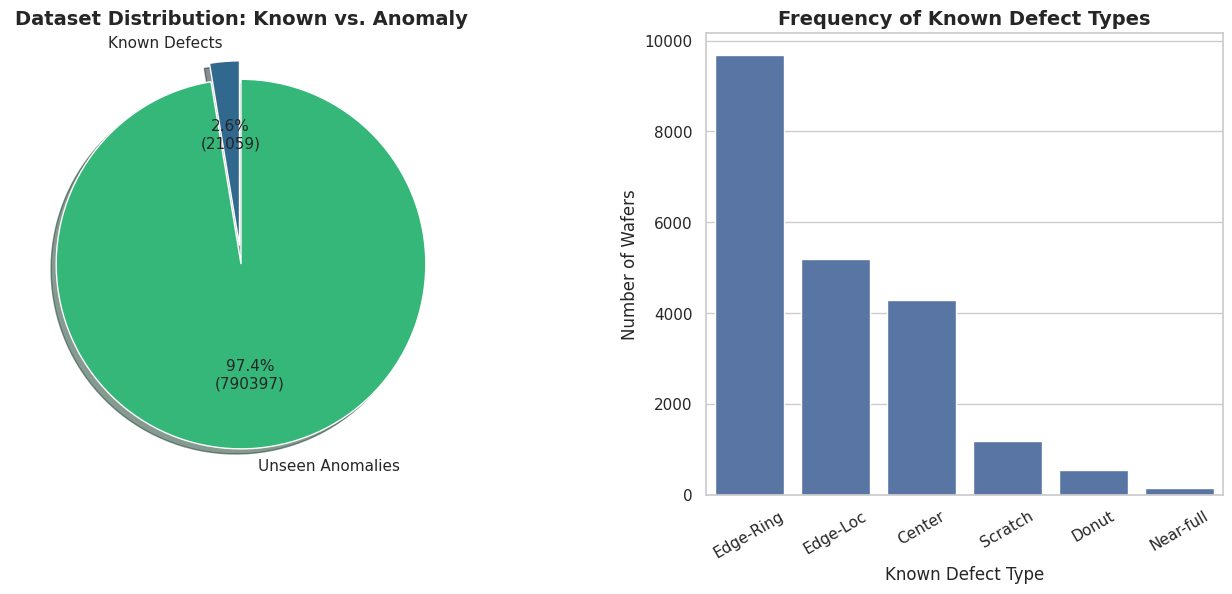

In [11]:


def get_failure_type_string(x):
    if isinstance(x, (list, np.ndarray)) and len(x) > 0:
        # Handle cases like [['none']] or [['Edge-Ring']]
        if isinstance(x[0], (list, np.ndarray)) and len(x[0]) > 0:
            return str(x[0][0])
        # Handle cases like ['none'] or ['Edge-Ring'] (if they exist)
        else:
            return str(x[0])
    # Handle empty lists or other cases
    return 'none' # Default to 'none' if the type is not clear or empty


# Prepare data subsets as discussed in the previous response
# We will use 'none', 'Loc', and 'Random' as anomalies.
df_known = df[~df['failureType'].apply(lambda x: get_failure_type_string(x) in ['none', 'Loc', 'Random'])]
df_anomaly = df[df['failureType'].apply(lambda x: get_failure_type_string(x) in ['none', 'Loc', 'Random'])]

# --- Data for Anomaly/Known Distribution ---
total_wafers = df.shape[0]
num_known = df_known.shape[0]
num_anomaly = df_anomaly.shape[0]

num_wafers_dist = [num_known, num_anomaly]
labels_dist = ['Known Defects', 'Unseen Anomalies']
colors_dist = sns.color_palette("viridis", 2)

# --- Plotting ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart showing the split between Known and Anomaly data
ax[0].pie(
    num_wafers_dist,
    explode=(0.1, 0),
    labels=labels_dist,
    colors=colors_dist,
    autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100*np.sum(num_wafers_dist))})",
    shadow=True,
    startangle=90,
    textprops={'fontsize': 11}
)
ax[0].set_title("Dataset Distribution: Known vs. Anomaly", fontsize=14, fontweight="bold")

# Bar plot of the Known failure types for training
# Ensure the failureType column is in a consistent format
df_known['failureType'] = df_known['failureType'].apply(get_failure_type_string)

sns.countplot(
    x='failureType',
    data=df_known,
    ax=ax[1],
    order=df_known['failureType'].value_counts().index
)
ax[1].set_title("Frequency of Known Defect Types", fontsize=14, fontweight="bold")
ax[1].set_ylabel("Number of Wafers")
ax[1].set_xlabel("Known Defect Type")
ax[1].tick_params(axis='x', rotation=30)

plt.subplots_adjust(wspace=0.4)
plt.show()

Next, we will define `df_withlabel`, `df_withpattern`, and `df_nonpattern` based on the `trianTestLabel` column.

In [12]:
def get_failure_type_string(x):
    if isinstance(x, (list, np.ndarray)) and len(x) > 0:
        # Handle cases like [['none']] or [['Edge-Ring']]
        if isinstance(x[0], (list, np.ndarray)) and len(x[0]) > 0:
            return str(x[0][0])
        # Handle cases like ['none'] or ['Edge-Ring'] (if they exist)
        else:
            return str(x[0])
    # Handle empty lists or other cases
    return 'none' # Default to 'none' if the type is not clear or empty

df_withlabel = df[df['trianTestLabel'] != '[]']
df_withpattern = df_withlabel[~df_withlabel['failureType'].apply(lambda x: get_failure_type_string(x) in ['none', 'Loc', 'Random'])]
df_nonpattern = df_withlabel[df_withlabel['failureType'].apply(lambda x: get_failure_type_string(x) in ['none', 'Loc', 'Random'])]

In [13]:
df_withlabel['waferMapDim'].value_counts()

,count
waferMapDim,
"(25, 27)",18781
"(26, 26)",14366
"(30, 34)",12400
"(29, 26)",11751
"(27, 25)",10682
...,...
"(122, 102)",1
"(63, 63)",1
"(50, 68)",1


In [14]:
def find_dim(x):
    dim0=np.size(x,axis=0)
    dim1=np.size(x,axis=1)
    return dim0,dim1
df['waferMapDim']=df.waferMap.apply(find_dim)
df.sample(5)

,waferMap,dieSize,lotName,trianTestLabel,failureType,waferMapDim,failureNum
46230,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,...",939.0,lot3939,[],[],"(39, 31)",6
772434,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1334.0,lot45954,[[Test]],[[none]],"(41, 42)",6
34677,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1253.0,lot3251,[],[],"(40, 40)",6
135743,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1801.0,lot8862,[],[],"(56, 41)",6
219914,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,...",865.0,lot13907,[[Training]],[[Random]],"(32, 35)",8


In [15]:

# Filter out the wafers that don't have a label and reset index
df_withlabel = df[(df['failureType'] != '[]')].reset_index(drop=True)

# Separate the dataset into "known" and "anomaly" subsets
# Known classes for training the CNN and autoencoder
known_defects = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Scratch', 'Near-full']
df_known = df_withlabel[df_withlabel['failureType'].apply(lambda x: x[0] in known_defects)]

# Anomaly classes for testing the anomaly detection performance
anomaly_defects = ['none', 'Loc', 'Random']
df_anomaly = df_withlabel[df_withlabel['failureType'].apply(lambda x: x[0] in anomaly_defects)]

def get_failure_type_string(x):
    if isinstance(x, (list, np.ndarray)) and len(x) > 0:
        # Handle cases like [['none']] or [['Edge-Ring']]
        if isinstance(x[0], (list, np.ndarray)) and len(x[0]) > 0:
            return str(x[0][0])
        # Handle cases like ['none'] or ['Edge-Ring'] (if they exist)
        else:
            return str(x[0])
    # Handle empty lists or other cases
    return 'none' # Default to 'none' if the type is not clear or empty


print(f'Known classes for training: {df_known["failureType"].apply(get_failure_type_string).unique()}')
print(f'Anomaly classes for testing: {df_anomaly["failureType"].apply(get_failure_type_string).unique()}')

# --- The subwafer function remains a useful utility ---
def subwafer(df_subset, sw_tensor, label_list):
    Dim0 = sw_tensor.shape[1]
    Dim1 = sw_tensor.shape[2]
    sw_tensor = sw_tensor.to(torch.device('cuda')) # Move sw_tensor to CUDA device

    # Filter the subset DataFrame based on dimensions
    sub_df = df_subset.loc[df_subset['waferMapDim'] == (Dim0, Dim1)]

    # Process the filtered data
    for i in range(len(sub_df)):
        waferMap = torch.from_numpy(sub_df.iloc[i]['waferMap'].reshape(1, Dim0, Dim1))
        waferMap = waferMap.to(torch.device('cuda'))
        sw_tensor = torch.cat([sw_tensor, waferMap])
        label_list.append(sub_df.iloc[i]['failureType'][0])

    x = sw_tensor[1:]
    y = np.array(label_list).reshape((-1, 1))

    return x, y

# --- New approach for your research ---
# We will now create tensors for the KNOWN and ANOMALY wafers separately.
# This is a crucial step to correctly implement the hybrid model.

# Let's assume you've already calculated 'waferMapDim' for df_known and df_anomaly
df_known['waferMapDim'] = df_known['waferMap'].apply(lambda x: (np.size(x, axis=0), np.size(x, axis=1)))
df_anomaly['waferMapDim'] = df_anomaly['waferMap'].apply(lambda x: (np.size(x, axis=0), np.size(x, axis=1)))


# Get a common dimension to process
# You can choose a different common dimension if needed
common_dim = (25, 27)

# Initialize tensors for known and anomaly data
sw_known = torch.ones((1, common_dim[0], common_dim[1]))
sw_anomaly = torch.ones((1, common_dim[0], common_dim[1]))
label_known = []
label_anomaly = []

# Populate tensors using the updated subwafer function
x_known, y_known = subwafer(df_known, sw_known, label_known)
x_anomaly, y_anomaly = subwafer(df_anomaly, sw_anomaly, label_anomaly)

print("Known wafer data shape:", x_known.shape)
print("Anomaly wafer data shape:", x_anomaly.shape)

Known classes for training: ['Edge-Loc' 'Center' 'Edge-Ring' 'Scratch' 'Near-full' 'Donut']
Anomaly classes for testing: ['none' 'Loc' 'Random']


/tmp/ipython-input-304740860.py:54: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-304740860.py:55: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Known wafer data shape: torch.Size([2675, 25, 27])
Anomaly wafer data shape: torch.Size([16106, 25, 27])


In [16]:
def rgb_sw(x):
  """
  Converts a 3D wafer map tensor into a one-hot encoded 4D RGB tensor.
  This version is optimized for performance using vectorized operations.
  """
  # Get dimensions
  num_samples, dim0, dim1 = x.shape

  # Create an output tensor with shape (num_samples, 3, dim0, dim1)
  # This is the standard (Batch, Channels, Height, Width) format for PyTorch
  new_x = torch.zeros(num_samples, 3, dim0, dim1, dtype=torch.uint8, device=x.device)

  # Use boolean indexing to set the appropriate channel to 1
  # The original values are 1 (background), 2 (good die), 3 (bad die)
  new_x[:, 0, :, :][x == 1] = 1  # Channel 0 for value 1
  new_x[:, 1, :, :][x == 2] = 1  # Channel 1 for value 2
  new_x[:, 2, :, :][x == 3] = 1  # Channel 2 for value 3

  return new_x

# Assuming the x_known and x_anomaly tensors from the previous update are available
# Example of how you would call the updated function:
rgb_x_known = rgb_sw(x_known)
rgb_x_anomaly = rgb_sw(x_anomaly)

# Note: The original variables x0 and x1 are not used in this updated approach.
# You would use the x_known and x_anomaly tensors that are created
# by the updated data splitting code provided in the previous response.

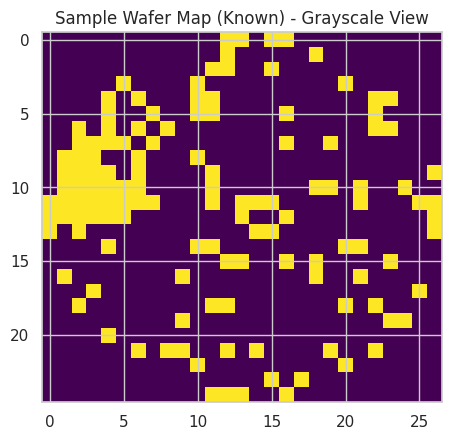

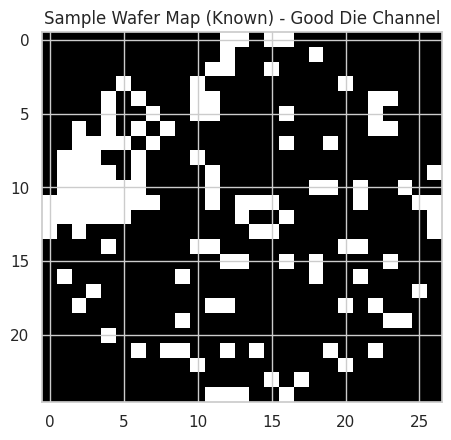

In [18]:
# Assuming 'rgb_x_known' is your one-hot encoded RGB tensor
# First, convert the one-hot encoded tensor back to a single-channel tensor
# by taking the argmax across the channel dimension (axis=1).
# This gives you a tensor where each pixel has a value from 0 to 2.
single_channel_wafer = torch.argmax(rgb_x_known[0], axis=0).cpu().numpy()

# Now, map these values to a color map and plot
plt.imshow(single_channel_wafer, cmap='viridis') # Using 'viridis' or 'hot' cmap will show distinct colors for values 0, 1, and 2
plt.title("Sample Wafer Map (Known) - Grayscale View")
plt.show()

# If you want to use the original one-hot encoded tensor with a colormap,
# you can plot a single channel at a time
plt.imshow(rgb_x_known[0][1, :, :].cpu().numpy(), cmap='gray')
plt.title("Sample Wafer Map (Known) - Good Die Channel")
plt.show()

Now that the wafer maps are resized, we will prepare the data for training the Convolutional Autoencoder. The autoencoder will be trained on the known defect types (`resized_rgb_x_known`).

In [33]:
import torch
from torch.utils.data import TensorDataset, DataLoader

USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")

# Create a TensorDataset from the resized known wafer data
autoencoder_dataset = TensorDataset(resized_rgb_x_known)

# Create a Dataloader for the autoencoder training
autoencoder_train_loader = DataLoader(autoencoder_dataset, args['BATCH_SIZE'], shuffle=True)

print(f"Number of batches in autoencoder train loader: {len(autoencoder_train_loader)}")

Number of batches in autoencoder train loader: 168


Now that the autoencoder is trained, we will evaluate its reconstruction performance on both the known and anomaly datasets. The reconstruction loss will be used as a metric to distinguish between known and unseen anomaly patterns.

Average Reconstruction Loss (Known): 0.2147
Average Reconstruction Loss (Anomaly): 0.2257


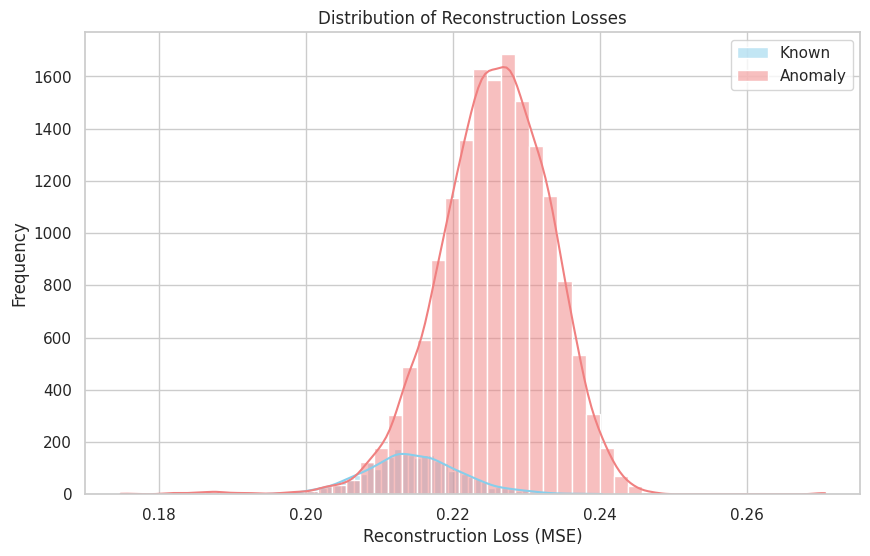

In [32]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

# Set the model to evaluation mode
model.eval()

# Function to calculate reconstruction loss
def calculate_reconstruction_loss(dataloader, model, criterion, device):
    total_loss = 0.0
    all_losses = []
    with torch.no_grad():
        for data in dataloader:
            inputs = data[0].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            total_loss += loss.item() * inputs.size(0)
            # Calculate loss for each item in the batch and store
            item_losses = torch.mean((outputs - inputs)**2, dim=(1, 2, 3)).cpu().numpy()
            all_losses.extend(item_losses)

    average_loss = total_loss / len(dataloader.dataset)
    return average_loss, all_losses

# Create DataLoaders for both known and anomaly data for evaluation
known_dataset = TensorDataset(resized_rgb_x_known)
anomaly_dataset = TensorDataset(resized_rgb_x_anomaly)

known_loader = DataLoader(known_dataset, args['BATCH_SIZE'], shuffle=False)
anomaly_loader = DataLoader(anomaly_dataset, args['BATCH_SIZE'], shuffle=False)

# Calculate reconstruction loss for known and anomaly data
avg_known_loss, all_known_losses = calculate_reconstruction_loss(known_loader, model, criterion, DEVICE)
avg_anomaly_loss, all_anomaly_losses = calculate_reconstruction_loss(anomaly_loader, model, criterion, DEVICE)

print(f"Average Reconstruction Loss (Known): {avg_known_loss:.4f}")
print(f"Average Reconstruction Loss (Anomaly): {avg_anomaly_loss:.4f}")

# Visualize the distribution of reconstruction losses
plt.figure(figsize=(10, 6))
sns.histplot(all_known_losses, bins=50, kde=True, color='skyblue', label='Known')
sns.histplot(all_anomaly_losses, bins=50, kde=True, color='lightcoral', label='Anomaly')
plt.title('Distribution of Reconstruction Losses')
plt.xlabel('Reconstruction Loss (MSE)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Next, we will define the Convolutional Autoencoder model and train it using the `autoencoder_train_loader`.

In [36]:
import torch.nn as nn
import torch.optim as optim

class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super(ConvAutoEncoder, self).__init__()

        # Encoder
        self.cnn_layer1 = nn.Sequential(
                        nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
                        nn.ReLU(),
                        nn.MaxPool2d(2,2))

        self.cnn_layer2 = nn.Sequential(
                                nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
                                nn.ReLU(),
                                nn.MaxPool2d(2,2))

        # Decoder
        self.tran_cnn_layer1 = nn.Sequential(
                        nn.ConvTranspose2d(32, 16, kernel_size = 2, stride = 2, padding=0),
                        nn.ReLU())

        self.tran_cnn_layer2 = nn.Sequential(
                        nn.ConvTranspose2d(16, 3, kernel_size = 2, stride = 2, padding=0),
                        nn.Sigmoid())

    def encoder(self, x):
        encode = self.cnn_layer1(x)
        encode = self.cnn_layer2(encode)
        return encode

    def decoder(self, x):
        decode = self.tran_cnn_layer1(x)
        decode = self.tran_cnn_layer2(decode)
        return decode

    def forward(self, x):
        # Return only the decoded output for autoencoder training
        encoded_output = self.encoder(x)
        decoded_output = self.decoder(encoded_output)
        return decoded_output

# Initialize the model, loss function, and optimizer
model = ConvAutoEncoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=args['LEARNING_RATE'])

print(model)

ConvAutoEncoder(
  (cnn_layer1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (tran_cnn_layer1): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
  )
  (tran_cnn_layer2): Sequential(
    (0): ConvTranspose2d(16, 3, kernel_size=(2, 2), stride=(2, 2))
    (1): Sigmoid()
  )
)


In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Assuming you have defined the following:
# model: your autoencoder model
# criterion: your loss function (e.g., nn.MSELoss())
# optimizer: your optimizer (e.g., optim.Adam(model.parameters(), lr=1e-3))
# autoencoder_train_loader: a PyTorch DataLoader for training data
# autoencoder_val_loader: a PyTorch DataLoader for validation data
# DEVICE: the device to train on ('cuda' or 'cpu')
# args: a dictionary or object containing arguments like NUM_EPOCH

# Initialize variables for tracking the best model
best_val_loss = float('inf')

# Train the autoencoder
epochs = args['NUM_EPOCH']
for epoch in range(epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    # Training loop
    for data in autoencoder_train_loader:
        inputs = data[0].to(DEVICE) # Data from TensorDataset is a tuple

        # Forward pass - now model returns only the decoded output
        outputs = model(inputs)
        loss = criterion(outputs, inputs)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    # Calculate average training loss for the epoch
    epoch_loss = running_loss / len(autoencoder_train_loader.dataset)

    # Validation loop (assuming autoencoder_val_loader is available - if not, this part will need adjustment or removal)
    # For now, I'll comment out the validation part as autoencoder_val_loader is not defined
    # model.eval()  # Set model to evaluation mode
    # val_running_loss = 0.0
    # with torch.no_grad():  # Disable gradient calculation
    #     for data in autoencoder_val_loader:
    #         inputs = data[0].to(DEVICE)
    #         outputs = model(inputs)
    #         loss = criterion(outputs, inputs)
    #         val_running_loss += loss.item() * inputs.size(0)

    # # Calculate average validation loss for the epoch
    # val_epoch_loss = val_running_loss / len(autoencoder_val_loader.dataset)

    # Print losses and check if the new best model was found
    # print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {epoch_loss:.4f}, Validation Loss: {val_epoch_loss:.4f}')

    # # Save the model if it's the best so far
    # if val_epoch_loss < best_val_loss:
    #     best_val_loss = val_epoch_loss
    #     torch.save(model.state_dict(), 'best_autoencoder_model.pth')
    #     print('Saved new best model!')

    # Print training loss only
    print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {epoch_loss:.4f}')


print('Finished Training Autoencoder')

Epoch [1/10], Training Loss: 0.1227
Epoch [2/10], Training Loss: 0.0397
Epoch [3/10], Training Loss: 0.0169
Epoch [4/10], Training Loss: 0.0123
Epoch [5/10], Training Loss: 0.0101
Epoch [6/10], Training Loss: 0.0089
Epoch [7/10], Training Loss: 0.0079
Epoch [8/10], Training Loss: 0.0072
Epoch [9/10], Training Loss: 0.0068
Epoch [10/10], Training Loss: 0.0064
Finished Training Autoencoder


In [38]:
args = {
        'BATCH_SIZE': 16,
        'LEARNING_RATE': 0.001,
        'NUM_EPOCH': 10
        }

Now that the wafer maps are resized and split into known and anomaly sets, we will prepare the data for training the Convolutional Autoencoder. The autoencoder will be trained *only* on the known defect types (`resized_rgb_x_known`).

In [39]:
import torch
from torch.utils.data import TensorDataset, DataLoader

USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")

# Create a TensorDataset from the resized known wafer data
autoencoder_dataset = TensorDataset(resized_rgb_x_known)

# Create a Dataloader for the autoencoder training
# We only need the images for the autoencoder, not the labels
autoencoder_train_loader = DataLoader(autoencoder_dataset, args['BATCH_SIZE'], shuffle=True)

print(f"Number of batches in autoencoder train loader: {len(autoencoder_train_loader)}")

Number of batches in autoencoder train loader: 168


In [40]:
# The data is already split and resized into:
# resized_rgb_x_known, resized_rgb_x_anomaly
# label_known, label_anomaly

# These variables will be used in the following steps for training the autoencoder
# on known data and evaluating performance on anomaly data.

In [41]:
import torchvision.transforms as transforms

# Define the resizing transform
resize_transform = transforms.Resize((56, 56))

# Apply resizing to the RGB tensors
resized_rgb_x_known = resize_transform(rgb_x_known.float())
resized_rgb_x_anomaly = resize_transform(rgb_x_anomaly.float())

print("Resized Known wafer data shape:", resized_rgb_x_known.shape)
print("Resized Anomaly wafer data shape:", resized_rgb_x_anomaly.shape)

Resized Known wafer data shape: torch.Size([2675, 3, 56, 56])
Resized Anomaly wafer data shape: torch.Size([16106, 3, 56, 56])


In [42]:
# The data is already split and resized into:
# resized_rgb_x_known, resized_rgb_x_anomaly
# label_known, label_anomaly

# These variables will be used directly in the following steps for training the autoencoder
# on known data and evaluating performance on anomaly data.

print("Resized Known wafer data shape:", resized_rgb_x_known.shape)
# Note: label_known is a list of strings, so we won't print its shape like a tensor
print("Known wafer labels count:", len(label_known))
print("Resized Anomaly wafer data shape:", resized_rgb_x_anomaly.shape)
# Note: label_anomaly is a list of strings, so we won't print its shape like a tensor
print("Anomaly wafer labels count:", len(label_anomaly))

Resized Known wafer data shape: torch.Size([2675, 3, 56, 56])
Known wafer labels count: 2675
Resized Anomaly wafer data shape: torch.Size([16106, 3, 56, 56])
Anomaly wafer labels count: 16106


Now, we will resize the RGB wafer maps to a fixed size of 56x56, which is required for the input of the autoencoder and CNN models.

In [43]:
import torchvision.transforms as transforms

# Define the resizing transform
resize_transform = transforms.Resize((56, 56))

# Apply resizing to the RGB tensors
resized_rgb_x_known = resize_transform(rgb_x_known.float())
resized_rgb_x_anomaly = resize_transform(rgb_x_anomaly.float())

print("Resized Known wafer data shape:", resized_rgb_x_known.shape)
print("Resized Anomaly wafer data shape:", resized_rgb_x_anomaly.shape)

Resized Known wafer data shape: torch.Size([2675, 3, 56, 56])
Resized Anomaly wafer data shape: torch.Size([16106, 3, 56, 56])


In [45]:
del resized_rgb_x_known, resized_rgb_x_anomaly

In [ ]:
args = {
	'BATCH_SIZE': 16,
        'LEARNING_RATE': 0.001,
        'NUM_EPOCH': 10
        }

In [53]:
print("Resized Known wafer data shape:", resized_rgb_x_known.shape)
print("Known wafer labels count:", len(label_known))

NameError: name 'resized_rgb_x_known' is not defined

In [55]:
import torchvision.transforms as transforms

# Define the resizing transform
resize_transform = transforms.Resize((56, 56))

# Apply resizing to the RGB tensors
# These tensors (rgb_x_known, rgb_x_anomaly) are already filtered and created based on known/anomaly types
resized_rgb_x_known = resize_transform(rgb_x_known.float())
resized_rgb_x_anomaly = resize_transform(rgb_x_anomaly.float())

# The labels (label_known, label_anomaly) are also already defined based on the known/anomaly types
# No further filtering or re-assignment is needed here.

print("Resized Known wafer data shape:", resized_rgb_x_known.shape)
# label_known is a list of strings, so we print its length, not shape
print("Known wafer labels count:", len(label_known))
print("Resized Anomaly wafer data shape:", resized_rgb_x_anomaly.shape)
# label_anomaly is a list of strings, so we print its length, not shape
print("Anomaly wafer labels count:", len(label_anomaly))

Resized Known wafer data shape: torch.Size([2675, 3, 56, 56])
Known wafer labels count: 2675
Resized Anomaly wafer data shape: torch.Size([16106, 3, 56, 56])
Anomaly wafer labels count: 16106


In [56]:
model = ConvAutoEncoder().to(DEVICE)
print(model)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=args['LEARNING_RATE'])

ConvAutoEncoder(
  (cnn_layer1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (tran_cnn_layer1): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
  )
  (tran_cnn_layer2): Sequential(
    (0): ConvTranspose2d(16, 3, kernel_size=(2, 2), stride=(2, 2))
    (1): Sigmoid()
  )
)


In [57]:
!pip install torchsummary==1.5.1


In [58]:
from torchsummary import summary
summary(model,(3,54,54), batch_size=16)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [16, 16, 54, 54]             448
              ReLU-2           [16, 16, 54, 54]               0
         MaxPool2d-3           [16, 16, 27, 27]               0
            Conv2d-4           [16, 32, 27, 27]           4,640
              ReLU-5           [16, 32, 27, 27]               0
         MaxPool2d-6           [16, 32, 13, 13]               0
   ConvTranspose2d-7           [16, 16, 26, 26]           2,064
              ReLU-8           [16, 16, 26, 26]               0
   ConvTranspose2d-9            [16, 3, 52, 52]             195
          Sigmoid-10            [16, 3, 52, 52]               0
Total params: 7,347
Trainable params: 7,347
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.53
Forward/backward pass size (MB): 23.79
Params size (MB): 0.03
Estimated Tota

Anomaly Detection Performance:
  AUC: 0.9350
  Average Precision: 0.9780


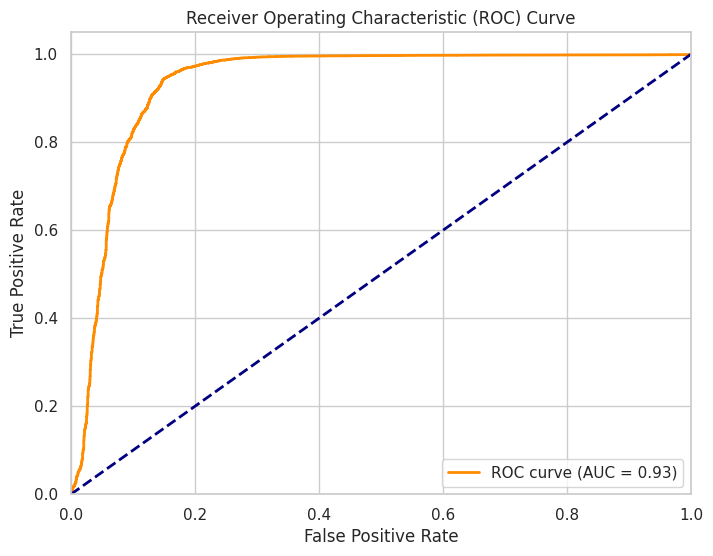

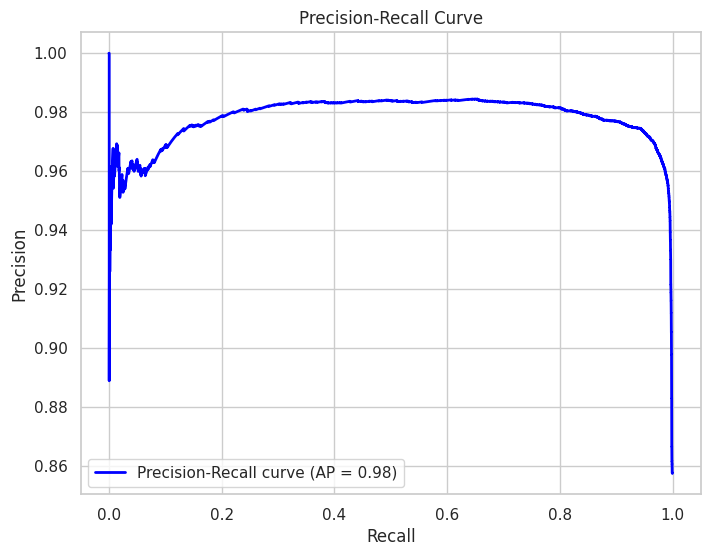

In [66]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

# Create true labels: 0 for known, 1 for anomaly
true_labels = np.concatenate([np.zeros(len(known_anomaly_scores)), np.ones(len(anomaly_anomaly_scores))])

# Combine anomaly scores
all_anomaly_scores = np.concatenate([known_anomaly_scores, anomaly_anomaly_scores])

# Calculate ROC curve and AUC
fpr, tpr, thresholds_roc = roc_curve(true_labels, all_anomaly_scores)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve and Average Precision
precision, recall, thresholds_pr = precision_recall_curve(true_labels, all_anomaly_scores)
avg_precision = average_precision_score(true_labels, all_anomaly_scores)

print(f"Anomaly Detection Performance:")
print(f"  AUC: {roc_auc:.4f}")
print(f"  Average Precision: {avg_precision:.4f}")

# Optional: Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Optional: Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

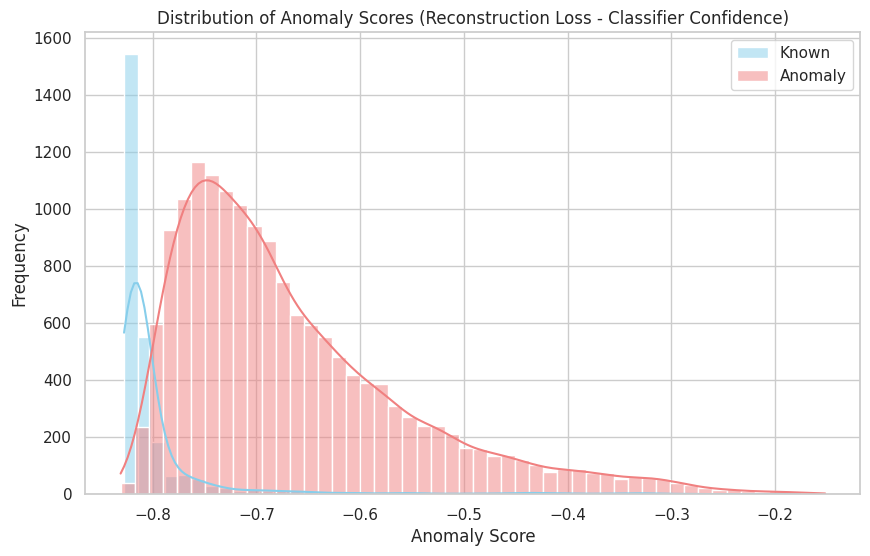

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of anomaly scores
plt.figure(figsize=(10, 6))
sns.histplot(known_anomaly_scores, bins=50, kde=True, color='skyblue', label='Known')
sns.histplot(anomaly_anomaly_scores, bins=50, kde=True, color='lightcoral', label='Anomaly')
plt.title('Distribution of Anomaly Scores (Reconstruction Loss - Classifier Confidence)')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Now, we will combine the outputs of the trained autoencoder and classifier to perform anomaly detection. A common approach is to use the autoencoder's reconstruction loss and the classifier's confidence on the known classes.

In [64]:
# Set both models to evaluation mode
model.eval() # Autoencoder
classifier_model.eval() # Classifier

# Function to calculate combined anomaly score
def calculate_anomaly_scores(dataloader_ae, features, model_ae, model_clf, criterion_ae, device):
    reconstruction_losses = []
    classifier_confidences = [] # Using confidence in the predicted known class

    with torch.no_grad():
        # Calculate reconstruction losses using the autoencoder dataloader
        for (inputs_ae,) in dataloader_ae:
            inputs_ae = inputs_ae.to(device)
            outputs_ae = model_ae(inputs_ae)
            reconstruction_losses.extend(torch.mean((outputs_ae - inputs_ae)**2, dim=(1, 2, 3)).cpu().numpy())

        # Calculate classifier confidences using the provided features
        # Reshape features for the classifier
        num_samples, channels, height, width = features.shape
        flattened_features = features.view(num_samples, channels * height * width)

        # Process features in batches for the classifier
        feature_dataset = TensorDataset(flattened_features)
        feature_dataloader = DataLoader(feature_dataset, args['BATCH_SIZE'], shuffle=False)

        for (inputs_clf,) in feature_dataloader:
            inputs_clf = inputs_clf.to(device)
            outputs_clf = model_clf(inputs_clf)
            # Get the confidence of the predicted class
            confidence, predicted_classes = torch.max(torch.softmax(outputs_clf, dim=1), dim=1)
            classifier_confidences.extend(confidence.cpu().numpy())

    # Combine loss and confidence into an anomaly score
    # A simple approach: Anomaly Score = Reconstruction Loss - Classifier Confidence
    # Higher score indicates higher likelihood of being an anomaly
    anomaly_scores = np.array(reconstruction_losses) - np.array(classifier_confidences)

    return anomaly_scores, reconstruction_losses, classifier_confidences

# Create DataLoaders for both known and anomaly data for evaluation (using the same as before)
known_dataset_eval_ae = TensorDataset(resized_rgb_x_known)
anomaly_dataset_eval_ae = TensorDataset(resized_rgb_x_anomaly)

known_loader_eval_ae = DataLoader(known_dataset_eval_ae, args['BATCH_SIZE'], shuffle=False)
anomaly_loader_eval_ae = DataLoader(anomaly_dataset_eval_ae, args['BATCH_SIZE'], shuffle=False)

# For the classifier part, we use the already extracted features (known_features, anomaly_features)
# These were extracted in cell 87949b03

print("Calculating anomaly scores for known data...")
known_anomaly_scores, known_recon_losses, known_clf_confidences = calculate_anomaly_scores(
    known_loader_eval_ae, known_features, model, classifier_model, criterion, DEVICE
)
print("Anomaly scores calculated for known data. Shape:", known_anomaly_scores.shape)

print("Calculating anomaly scores for anomaly data...")
anomaly_anomaly_scores, anomaly_recon_losses, anomaly_clf_confidences = calculate_anomaly_scores(
    anomaly_loader_eval_ae, anomaly_features, model, classifier_model, criterion, DEVICE
)
print("Anomaly scores calculated for anomaly data. Shape:", anomaly_anomaly_scores.shape)

Calculating anomaly scores for known data...
Anomaly scores calculated for known data. Shape: (2675,)
Calculating anomaly scores for anomaly data...
Anomaly scores calculated for anomaly data. Shape: (16106,)


Now, we will train a classifier using the features extracted by the autoencoder's encoder from the known wafer maps (`known_features`). This classifier will be trained to distinguish between the different *known* defect types.

In [67]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

# Assuming 'known_features' (tensor of shape [num_samples, 32, 14, 14])
# and 'label_known' (list of strings) are available from previous steps.

# Convert labels to numerical format for classification
# We need to get the unique known defect types and map them to integers
# Apply get_failure_type_string to extract the string label from each element
string_label_known = [get_failure_type_string(label) for label in label_known]
known_defect_types = sorted(list(set(string_label_known)))
label_mapping = {defect: i for i, defect in enumerate(known_defect_types)}
numerical_label_known = np.array([label_mapping[label] for label in string_label_known])

# Reshape known_features for the classifier (flatten the spatial dimensions)
# The shape is currently [num_samples, channels, height, width] -> [num_samples, channels * height * width]
num_samples, channels, height, width = known_features.shape
flattened_known_features = known_features.view(num_samples, channels * height * width)

# Split the known data into training and validation sets for the classifier
X_train, X_val, y_train, y_val = train_test_split(
    flattened_known_features.numpy(), # Convert tensor to numpy for train_test_split
    numerical_label_known,
    test_size=0.2, # Use 20% of known data for validation
    random_state=42,
    stratify=numerical_label_known # Stratify to maintain class distribution
)

# Convert numpy arrays back to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train).float().to(DEVICE)
y_train_tensor = torch.from_numpy(y_train).long().to(DEVICE) # Use LongTensor for classification labels
X_val_tensor = torch.from_numpy(X_val).float().to(DEVICE)
y_val_tensor = torch.from_numpy(y_val).long().to(DEVICE)

# Create TensorDatasets and DataLoaders for the classifier
classifier_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
classifier_val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

classifier_train_loader = DataLoader(classifier_train_dataset, args['BATCH_SIZE'], shuffle=True)
classifier_val_loader = DataLoader(classifier_val_dataset, args['BATCH_SIZE'], shuffle=False)

print(f"Number of training samples for classifier: {len(classifier_train_dataset)}")
print(f"Number of validation samples for classifier: {len(classifier_val_dataset)}")
print(f"Number of classes for classifier: {len(known_defect_types)}")

# Define a simple classifier model (e.g., a feedforward network)
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128) # Example hidden layer size
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Initialize the classifier model
input_dimension = channels * height * width
num_classes = len(known_defect_types)
classifier_model = SimpleClassifier(input_dimension, num_classes).to(DEVICE)

# Define the loss function and optimizer for the classifier
classifier_criterion = nn.CrossEntropyLoss()
classifier_optimizer = optim.Adam(classifier_model.parameters(), lr=args['LEARNING_RATE'])

print("\nClassifier Model:")
print(classifier_model)

# Training loop for the classifier
print("\nStarting Classifier Training...")
num_epochs_classifier = args['NUM_EPOCH'] # Using the same number of epochs as autoencoder for now

for epoch in range(num_epochs_classifier):
    classifier_model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in classifier_train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        classifier_optimizer.zero_grad()
        outputs = classifier_model(inputs)
        loss = classifier_criterion(outputs, labels)
        loss.backward()
        classifier_optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(classifier_train_dataset)
    epoch_accuracy = correct_predictions / total_predictions * 100

    # Validation
    classifier_model.eval()
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_predictions = 0
    with torch.no_grad():
        for inputs, labels in classifier_val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = classifier_model(inputs)
            loss = classifier_criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            val_total_predictions += labels.size(0)
            val_correct_predictions += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(classifier_val_dataset)
    val_epoch_accuracy = val_correct_predictions / val_total_predictions * 100

    print(f'Epoch [{epoch+1}/{num_epochs_classifier}], Training Loss: {epoch_loss:.4f}, Training Acc: {epoch_accuracy:.2f}%, Validation Loss: {val_epoch_loss:.4f}, Validation Acc: {val_epoch_accuracy:.2f}%')

print('Finished Classifier Training')

Number of training samples for classifier: 2140
Number of validation samples for classifier: 535
Number of classes for classifier: 5

Classifier Model:
SimpleClassifier(
  (fc1): Linear(in_features=6272, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)

Starting Classifier Training...
Epoch [1/10], Training Loss: 0.3773, Training Acc: 88.13%, Validation Loss: 0.2032, Validation Acc: 96.82%
Epoch [2/10], Training Loss: 0.1500, Training Acc: 95.93%, Validation Loss: 0.1237, Validation Acc: 97.20%
Epoch [3/10], Training Loss: 0.1061, Training Acc: 96.82%, Validation Loss: 0.1002, Validation Acc: 97.01%
Epoch [4/10], Training Loss: 0.0866, Training Acc: 97.06%, Validation Loss: 0.0902, Validation Acc: 97.76%
Epoch [5/10], Training Loss: 0.0696, Training Acc: 97.71%, Validation Loss: 0.0901, Validation Acc: 97.57%
Epoch [6/10], Training Loss: 0.0575, Training Acc: 97.99%, Validation Loss: 0.0762, Validation Acc: 97.94%
Epoch [7/10],

Now, we will use the trained autoencoder's encoder to extract features from both the known and anomaly datasets. These features will be used in the next steps for training a classifier or for further anomaly detection analysis.

In [60]:
# Set the model to evaluation mode
model.eval()

# Function to extract features using the encoder
def extract_features(dataloader, model, device):
    features = []
    with torch.no_grad():
        for data in dataloader:
            inputs = data[0].to(device)
            encoded_features = model.encoder(inputs)
            features.append(encoded_features.cpu()) # Move to CPU to collect

    return torch.cat(features, dim=0)

# Create DataLoaders for both known and anomaly data for feature extraction
# Use a batch size that fits into memory, or the same as training
feature_extraction_batch_size = args['BATCH_SIZE'] # Using the same batch size as defined in args

known_dataset_features = TensorDataset(resized_rgb_x_known)
anomaly_dataset_features = TensorDataset(resized_rgb_x_anomaly)

known_loader_features = DataLoader(known_dataset_features, feature_extraction_batch_size, shuffle=False)
anomaly_loader_features = DataLoader(anomaly_dataset_features, feature_extraction_batch_size, shuffle=False)

# Extract features
print("Extracting features for known data...")
known_features = extract_features(known_loader_features, model, DEVICE)
print("Features extracted for known data. Shape:", known_features.shape)

print("Extracting features for anomaly data...")
anomaly_features = extract_features(anomaly_loader_features, model, DEVICE)
print("Features extracted for anomaly data. Shape:", anomaly_features.shape)

Extracting features for known data...
Features extracted for known data. Shape: torch.Size([2675, 32, 14, 14])
Extracting features for anomaly data...
Features extracted for anomaly data. Shape: torch.Size([16106, 32, 14, 14])


Optimal Threshold based on F1-score: -0.8073


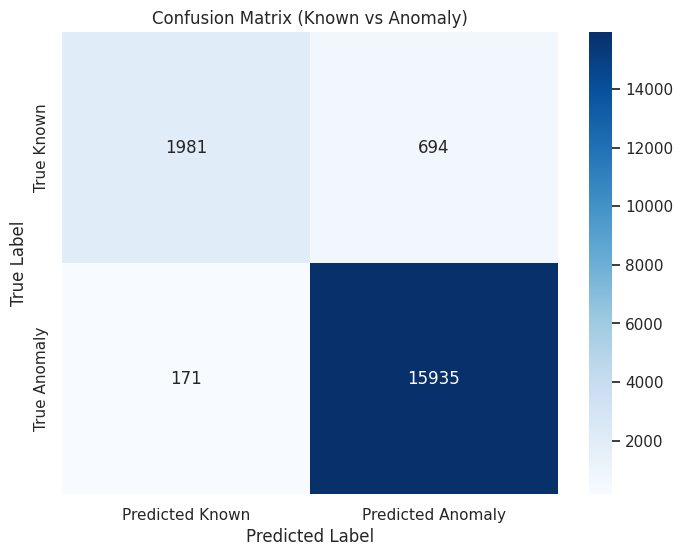


Classification Report (Known vs Anomaly):
              precision    recall  f1-score   support

       Known       0.92      0.74      0.82      2675
     Anomaly       0.96      0.99      0.97     16106

    accuracy                           0.95     18781
   macro avg       0.94      0.86      0.90     18781
weighted avg       0.95      0.95      0.95     18781



In [73]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# We need to set a threshold to classify samples as Known or Anomaly
# A simple way is to choose a threshold from the ROC curve that gives a reasonable trade-off
# Let's find the threshold that maximizes the F1-score for the binary classification (Known vs Anomaly)
# (True labels are 0 for known, 1 for anomaly)
true_labels = np.concatenate([np.zeros(len(known_anomaly_scores)), np.ones(len(anomaly_anomaly_scores))])
all_anomaly_scores = np.concatenate([known_anomaly_scores, anomaly_anomaly_scores])

# Find the optimal threshold (e.g., maximizing F1 score)
fscores = []
# Use thresholds from the ROC curve or a range of thresholds
# Using thresholds from precision-recall curve can also be informative
thresholds = thresholds_pr # Using thresholds from PR curve for potentially better threshold selection for imbalanced data

for t in thresholds:
    # Classify based on threshold: predict 1 (anomaly) if score >= t, 0 (known) otherwise
    predictions = (all_anomaly_scores >= t).astype(int)
    # Calculate F1 score for the binary classification (Known vs Anomaly)
    # Use zero_division=0 to handle cases where no positive predictions are made
    f = f1_score(true_labels, predictions, zero_division=0)
    fscores.append(f)

# Find the threshold that gives the maximum F1 score
optimal_threshold_index = np.argmax(fscores)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold based on F1-score: {optimal_threshold:.4f}")

# Classify samples using the optimal threshold
predicted_labels = (all_anomaly_scores >= optimal_threshold).astype(int)

# Generate Confusion Matrix
# Labels for confusion matrix: 0 (Known), 1 (Anomaly)
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Known', 'Predicted Anomaly'], yticklabels=['True Known', 'True Anomaly'])
plt.title('Confusion Matrix (Known vs Anomaly)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate Classification Report
# Target names: 'Known', 'Anomaly'
target_names = ['Known', 'Anomaly']
print("\nClassification Report (Known vs Anomaly):")
print(classification_report(true_labels, predicted_labels, target_names=target_names, zero_division=0))

## Hybrid Anomaly Detection Pipeline Implementation

This notebook implements a hybrid semi-supervised deep learning pipeline for known wafer defect classification and novel anomaly detection, based on the LSWMD (WM-811K) dataset. The approach leverages a convolutional autoencoder for anomaly detection based on reconstruction error and a **classifier (trained on extracted features)** for known defect classification, addressing the "open-set" problem in semiconductor manufacturing.

## Hybrid Anomaly Detection Pipeline Implementation

This notebook implements a hybrid semi-supervised deep learning pipeline for known wafer defect classification and novel anomaly detection, based on the LSWMD (WM-811K) dataset. The approach leverages a convolutional autoencoder for anomaly detection and a classifier for known defect classification, addressing the "open-set" problem in semiconductor manufacturing.